In [42]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models     
from tensorflow.keras.datasets import mnist


In [43]:
# 1. Load the data
# x_train: image data, y_train: labels (the actual number)
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Check the shape
print(f"Training data shape: {x_train.shape}") # Should be (60000, 28, 28)
print(f"Test data shape: {x_test.shape}")

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [44]:
# 2. Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0
# 3. Reshape for CNN (Batch Size, Height, Width, Color Channels)
# MNIST is grayscale, so channels = 1
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))
print("Data normalized and reshaped.")

Data normalized and reshaped.


In [45]:
model = models.Sequential([
# Layer 1: Convolution
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
# Layer 2: Convolution (capturing more complex features)
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
# Layer 3: Flattening
layers.Flatten(),
# Layer 4: Classification
layers.Dense(64, activation='relu'),
layers.Dropout(0.5), # Prevents memorization
layers.Dense(10, activation='softmax') # Output layer (0-9 probabilities)
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(optimizer='SGD',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

In [47]:
history = model.fit(x_train, y_train,
epochs=10,
batch_size=1,
validation_data=(x_test, y_test))

Epoch 1/10
16366/60000 ━━━━━━━━━━━━━━━━━━━━ 9:28 13ms/step - accuracy: 0.7416 - loss: 0.7682

KeyboardInterrupt: 

313/313 - 0s - 2ms/step - accuracy: 0.9929 - loss: 0.0299

Test accuracy: 0.9929


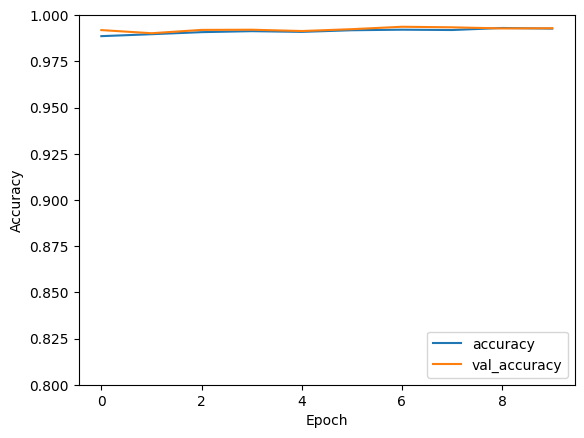

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')
# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1])
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Grab an image from the test set
img = x_test[0]
print(f"Actual Label: {y_test[0]}")
# Add batch dimension (1, 28, 28, 1) because model expects a batch
prediction = model.predict(np.expand_dims(img, axis=0))
# Get the index of the highest probability
predicted_label = np.argmax(prediction)
print(f"Predicted Label: {predicted_label}")

Actual Label: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted Label: 7


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


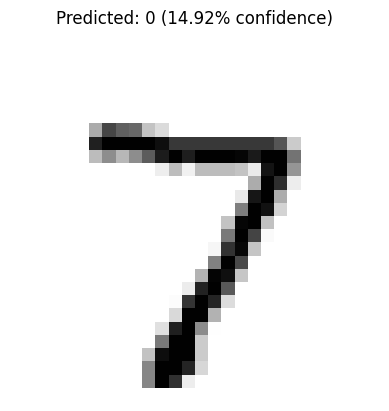

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_custom_image(image_path, model):
	# 1. Load image (grayscale, resize to 28x28)
	img = image.load_img(image_path, color_mode='grayscale', target_size=(28, 28))
# 2. Convert to array
img_array = image.img_to_array(img)
# 3. Invert colors (255 -> 0, 0 -> 255)
# Only do this if your image is black ink on white paper!
img_array = 255.0 - img_array
# 4. Normalize (0-1 range)
img_array /= 255.0
# 5. Reshape for model
img_array = img_array.reshape((1, 28, 28, 1))
# 6. Predict
prediction = model.predict(img_array)
predicted_label = np.argmax(prediction)
confidence = np.max(prediction)

# Display
plt.imshow(img_array.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_label} ({confidence:.2%} confidence)")
plt.axis('off')
plt.show()
# Usage Example:
# predict_custom_image('my_handwritten_digit.jpg', model)